# Batch fine-grained mask generation — all subjects

Generates four mutually exclusive `.mat` masks per subject in `eyemasks/`.
The `nomo_mask` (already generated by notebook 7) is **not** recomputed here;
`fixation_ok_mask` is identical to it by construction.

| File | Meaning |
|---|---|
| `*_fixation_ok_mask.mat` | fixation=1 with valid coordinates (≡ nomo_mask) |
| `*_saccade_only_mask.mat` | saccade=1 without blink |
| `*_blink_event_mask.mat` | blink (sub-event of saccade) |
| `*_tracking_loss_mask.mat` | unlabeled / tracking loss / inter-event gaps |


In [6]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt


In [7]:
STUDY_PATH   = Path('/home/debi/jaime/repos/MR-EyeTrack/data/study')
SUBJECT_LIST = list(range(1, 16))

# MRI acquisition duration in milliseconds (= ET samples at 1 kHz).
# Default matches the T1 LIBRE protocol. Override per subject if needed.
MRI_DURATION_MAP = {i: 659768 for i in SUBJECT_LIST}
# MRI_DURATION_MAP[1] = 511505

# ET-to-MRI sync offset in samples. 0 = already aligned.
OFFSET_MAP = {i: 0 for i in SUBJECT_LIST}


In [8]:
def process_subject(subject_idx, mri_duration, offset=0):
    print(f"\n{'='*60}")
    print(f'Processing sub-{subject_idx:03d}')

    BIDS_PATH    = STUDY_PATH / f'sub-{subject_idx:03d}/et'
    EYEMASK_PATH = STUDY_PATH / f'sub-{subject_idx:03d}/eyemasks'
    EYEMASK_PATH.mkdir(exist_ok=True)

    candidates = list(BIDS_PATH.glob('*.tsv.gz'))
    if not candidates:
        print(f'  [SKIP] No .tsv.gz file in {BIDS_PATH}')
        return None
    FILE_NAME      = candidates[0].stem.replace('.tsv', '')
    recording_file = BIDS_PATH / f'{FILE_NAME}.tsv.gz'

    recording = pd.read_csv(recording_file, sep='\t', na_values='n/a')
    print(f'  ET recording: {len(recording)} samples')

    recording = recording.rename(columns={
        'eye1_fixation':     'fixation',
        'eye1_saccade':      'saccade',
        'eye1_blink':        'blink',
        'eye1_x_coordinate': 'x_coordinate',
        'eye1_y_coordinate': 'y_coordinate',
    })

    # Trim to MRI acquisition window (no NaN-ing needed — use raw event flags directly)
    def _trim(df):
        return df.iloc[offset:].reset_index(drop=True).iloc[:mri_duration]

    rec = _trim(recording)
    print(f'  MRI window: {len(rec)} samples (requested {mri_duration})')

    # Original NaN status: coordinates missing at acquisition time (tracking loss)
    orig_nan = rec['x_coordinate'].isna() | rec['y_coordinate'].isna()

    # Four mutually exclusive masks (priority: blink > saccade > fixation > rest)
    is_blink         = rec['blink'].astype(bool)
    is_saccade_only  = rec['saccade'].astype(bool) & ~is_blink
    is_fixation_ok   = rec['fixation'].astype(bool) & ~is_saccade_only & ~is_blink & ~orig_nan
    is_tracking_loss = ~is_blink & ~is_saccade_only & ~is_fixation_ok

    fixation_ok_mask   = is_fixation_ok.astype(int).to_numpy()
    saccade_only_mask  = is_saccade_only.astype(int).to_numpy()
    blink_event_mask   = is_blink.astype(int).to_numpy()
    tracking_loss_mask = is_tracking_loss.astype(int).to_numpy()

    total = fixation_ok_mask + saccade_only_mask + blink_event_mask + tracking_loss_mask
    if not (total == 1).all():
        print(f'  [WARNING] Masks not mutually exclusive/exhaustive for sub-{subject_idx:03d}!')
    else:
        print(f'  Sanity check passed.')

    # Compare against existing nomo_mask if present
    nomo_path = EYEMASK_PATH / f'{FILE_NAME}_nomo_mask.mat'
    if nomo_path.exists():
        nomo_existing = sio.loadmat(nomo_path)['array'].ravel().astype(int)
        if len(nomo_existing) != len(fixation_ok_mask):
            print(f'  [MISMATCH] nomo_mask length {len(nomo_existing)} != fixation_ok length {len(fixation_ok_mask)}')
        elif np.array_equal(fixation_ok_mask, nomo_existing):
            print(f'  [OK] fixation_ok_mask == nomo_mask (all {len(nomo_existing)} samples match)')
        else:
            n_diff = int(np.sum(fixation_ok_mask != nomo_existing))
            idx    = np.where(fixation_ok_mask != nomo_existing)[0]
            print(f'  [MISMATCH] {n_diff} samples differ — first indices: {idx[:10]}')
    else:
        print(f'  [INFO] nomo_mask.mat not found, skipping comparison')

    for name, arr in [
        ('fixation_ok',   fixation_ok_mask),
        ('saccade_only',  saccade_only_mask),
        ('blink_event',   blink_event_mask),
        ('tracking_loss', tracking_loss_mask),
    ]:
        sio.savemat(EYEMASK_PATH / f'{FILE_NAME}_{name}_mask.mat', {'array': arr})
    print(f'  Saved 4 masks → {EYEMASK_PATH}')

    n = len(fixation_ok_mask)
    stats = {
        'subject':       subject_idx,
        'total':         n,
        'fixation_ok':   int(fixation_ok_mask.sum()),
        'saccade_only':  int(saccade_only_mask.sum()),
        'blink_event':   int(blink_event_mask.sum()),
        'tracking_loss': int(tracking_loss_mask.sum()),
    }
    for key in ('fixation_ok', 'saccade_only', 'blink_event', 'tracking_loss'):
        print(f'  {key:<16}: {stats[key]:>8}  ({stats[key]/n*100:.1f}%)')
    return stats


In [9]:
all_stats = []
for sub in SUBJECT_LIST:
    try:
        s = process_subject(sub, MRI_DURATION_MAP[sub], OFFSET_MAP[sub])
        if s is not None:
            all_stats.append(s)
    except Exception as e:
        print(f'  [ERROR] sub-{sub:03d}: {e}')

print(f'\nDone. Processed {len(all_stats)} / {len(SUBJECT_LIST)} subjects.')



Processing sub-001
  ET recording: 663027 samples
  MRI window: 659768 samples (requested 659768)
  Sanity check passed.
  [OK] fixation_ok_mask == nomo_mask (all 659768 samples match)
  Saved 4 masks → /home/debi/jaime/repos/MR-EyeTrack/data/study/sub-001/eyemasks
  fixation_ok     :   605053  (91.7%)
  saccade_only    :    12622  (1.9%)
  blink_event     :    40080  (6.1%)
  tracking_loss   :     2013  (0.3%)

Processing sub-002
  ET recording: 662902 samples
  MRI window: 659768 samples (requested 659768)
  Sanity check passed.
  [OK] fixation_ok_mask == nomo_mask (all 659768 samples match)
  Saved 4 masks → /home/debi/jaime/repos/MR-EyeTrack/data/study/sub-002/eyemasks
  fixation_ok     :   355351  (53.9%)
  saccade_only    :    15791  (2.4%)
  blink_event     :   284127  (43.1%)
  tracking_loss   :     4499  (0.7%)

Processing sub-003
  ET recording: 662485 samples
  MRI window: 659768 samples (requested 659768)
  Sanity check passed.
  [OK] fixation_ok_mask == nomo_mask (all 659

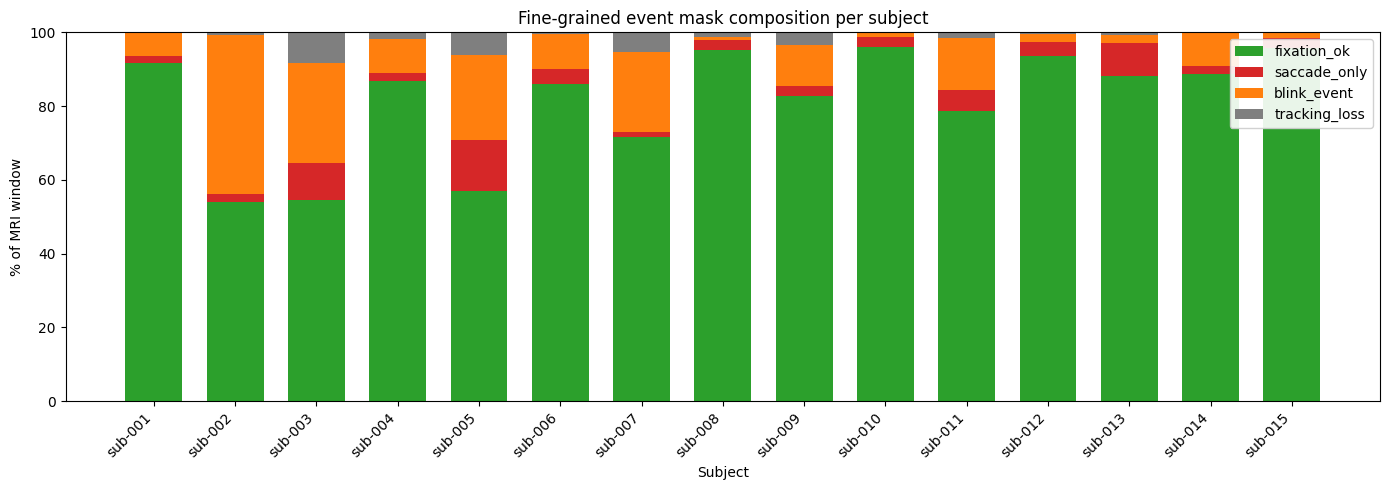

In [10]:
if not all_stats:
    print('No data to plot.')
else:
    df  = pd.DataFrame(all_stats).set_index('subject')
    pct = df[['fixation_ok', 'saccade_only', 'blink_event', 'tracking_loss']].div(df['total'], axis=0) * 100

    colors = ['#2ca02c', '#d62728', '#ff7f0e', '#7f7f7f']
    fig, ax = plt.subplots(figsize=(14, 5))
    bottom  = np.zeros(len(pct))
    for col, color in zip(pct.columns, colors):
        ax.bar(pct.index, pct[col], bottom=bottom, label=col, color=color, width=0.7)
        bottom += pct[col].values
    ax.set_xlabel('Subject')
    ax.set_ylabel('% of MRI window')
    ax.set_ylim(0, 100)
    ax.set_xticks(pct.index)
    ax.set_xticklabels([f'sub-{s:03d}' for s in pct.index], rotation=45, ha='right')
    ax.legend(loc='upper right', framealpha=0.9)
    ax.set_title('Fine-grained event mask composition per subject')
    plt.tight_layout()
    plt.show()
